<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW5_boosting_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашняя работа: прогнозирование заработной платы и кластеризация типов движений**

### **Постановка задачи:**

В этой работе две части:

*   В первой части вам предстоит построить алгоритм на основе бустинга для прогнозирования зарплаты
*   Во второй части вам предстоит кластеризовать типы движений по имеющимся данным с акселерометров и гироскопов

### **Оценивание:**

- Как всегда оцениваются как код, так и ответы на вопросы. Если нет одного и/или другого, то часть баллов за соответствующее задание без колебаний снимается.
- Брать код из открытых источников позволительно. Следование культуре цитирования **обязательно.**

### **Баллы:**

Суммарно за задание можно получить 10 основных и 1 бонусный балл.

Оценка за ДЗ = min{ваш балл, 10}

**Интересной вам работы!**


# P.S.
### Для сглаживания своих мыслей в выводах я использовал гптшку

# **Часть 1. Прогнозирование заработной платы при помощи бустинга**

**Количество баллов:** 7

## **Постановка задачи:**

Данные выгружены и лежат в файле `ds_salary.csv`. Вам доступны описания признаков и значения целевой переменной.

**Ваша задача:** построение модели бустинга и оценка данной модели.

## **Описание даных**

- work_year: год, в который взяты данные;
- experience_level: уровень опыта, кодируемый как SE, MI EN или EX
- employment_type: тип занятости (FT, PT, CT, FL)
- job_title: название рабочей позиции в компании;
- salary: зараплата на позиции;
- salary_currency: валюта в которой начисляют зарплату;
- employee_residence: страна или регион проживания сотрудника
- remote_ratio: процент удаленки, предлагаемый в компании (0, 50, 100)
- company_location: местоположение компании
- company_size: размер компании, оцененный как S, M, L
- salary_in_usd: целевая переменная


Как всегда, загрузим набор данных.

In [89]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import time

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, silhouette_score, adjusted_rand_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.cluster import SpectralClustering, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.image import img_to_graph

from scipy.stats import randint, uniform

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

from skimage import color, transform, img_as_float
from PIL import Image


In [90]:
df = pd.read_csv("https://github.com/hse-ds/iad-intro-ds/raw/refs/heads/master/2023/homeworks/hw-08-boosting/ds_salaries.csv")

## **Задание 1 (0.3 балла)**

Вам даны описания переменных. Проверьте, что категориальные признаки, категории которых перечислены, не имеют ошибочных значений. Для этого:

- Напишите цикл, пробегающий по выбранным признакам и оценивающий, что в них нет лишних значений;

In [91]:
categorical_cols = {
    'experience_level': ['SE', 'MI', 'EN', 'EX'],
    'employment_type': ['FT', 'PT', 'CT', 'FL'],
    'remote_ratio': [0, 50, 100],
    'company_size': ['S', 'M', 'L']
}

for col, valid_values in categorical_cols.items():
    unique_vals = df[col].unique()
    extra = set(unique_vals) - set(valid_values)

    print(f'{col}:')
    print('лишние значения:', len(extra))

experience_level:
лишние значения: 0
employment_type:
лишние значения: 0
remote_ratio:
лишние значения: 0
company_size:
лишние значения: 0


## **Задание 2 (0.3 балла)**

Проведите базовые шаги оценки качества данных.
- Есть есть проблемы, устраните их;
- Если нет проблем, кратко опишите это.

In [92]:
print(df.isnull().sum())
print()
print('duplicates:', df.duplicated().sum())
print()
print(df.dtypes)
print()
print(df.describe())

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

duplicates: 1171

work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

         work_year        salary  salary_in_usd  remote_ratio
count  3755.000000  3.755000e+03    3755.000000   3755.000000
mean   2022.373635  1.906956e+05  137570.389880     46.271638
std       0.691448  6.716765e+05   63055.625278     48.589050
min    2020.000000  6.000000e+03    5132.000000      0.000000
25%    2022.000000  1.000000e+05   95000.000000      0.00000

В данных отсутствуют пропуски, типы признаков корректные. Категориальные признаки содержат разумное количество уникальных значений и соответствуют описанию.

Однако обнаружено 1171 дубликатов, которые следует удалить.

In [93]:
df = df.drop_duplicates()

## **Задание 3 (0.3 балла)**

Вернитесь к описанию признаков.
- Проверьте, все ли признаки соответствуют постановке задачи? Если есть лишние признаки, удалите их и обоснуйте удаление, если нет, сделайте вывод о релевантности (достаточно в одну-две строки)
- Зафиксируйте, в каких признаках много категорий.

In [94]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].nunique())

df = df.drop(columns=['salary'])
df = df.drop(columns=['salary_currency'])

experience_level 4
employment_type 4
job_title 93
salary_currency 20
employee_residence 78
company_location 72
company_size 3


Признаки salary и salary_currency избыточены, так как уже есть salary_in_usd, приведённый к одной валюте, поэтому их можно удалить.

Наибольшее количество категорий наблюдается в признаках job_title, employee_residence, company_location и salary_currency. Эти признаки потенциально сложны для обработки и могут потребовать дополнительной предобработки.

## **Задание 4 (0.2 балла)**

Разделите выборку на train, test (80%, 20%).

In [95]:
X = df.drop(columns=['salary_in_usd'])
y = df['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## **Задание 5 (0.3 балла)**

Будем проверять два сценария. Первый — построение модели только на непрерывных признаках, а второй — построение с категориальными. В этом задании подготовьте всё, чтобы проверить валидность обоих сценариев. А именно:

- Выделите данные для тренировки и теста для непрерывных признаков
- Выделите данные для тренировки и теста для непрерывных + категориальных признаков, пока ничего не кодируйте.

In [96]:
num_cols = X_train.select_dtypes(exclude='object').columns

X_train_num = X_train[num_cols]
X_test_num = X_test[num_cols]

X_train_full = X_train.copy()
X_test_full = X_test.copy()

print(X_train_num.shape, X_test_num.shape)
print(X_train_full.shape, X_test_full.shape)

(2067, 2) (517, 2)
(2067, 8) (517, 8)


## **Задание 6 (0.2 балла)**

- Обучите модель линейной регресии на числовых признаках и оцените её качество через mape и rmse;
- Сделайте вывод о качестве построенной модели;

In [97]:
model = LinearRegression()
model.fit(X_train_num, y_train)

y_pred = model.predict(X_test_num)

mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('MAPE:', mape)
print('RMSE:', rmse)

MAPE: 0.829056639955772
RMSE: 64000.532625649634


Модель показывает низкое качество. Значение MAPE ≈ 0.83 (83%) говорит о том, что в среднем ошибка предсказания очень большая в относительном выражении. RMSE также высокий, что указывает на сильные отклонения предсказаний от реальных значений.

Основная причина это использование только числовых признаков и линейной модели, которая не способна уловить сложные зависимости в данных.

## **Задание 8 (0.2 балла)**

- Обучите модель бустинга (любую из трех библиотек catboost, xgboost, lightgbm) с гиперпараметрами по умолчанию на непрерывных признаках и оцените её качество через mape и rmse;
- Сделайте вывод о качестве построенной модели;

In [98]:
model = LGBMRegressor(random_state=42)
model.fit(X_train_num, y_train)

y_pred = model.predict(X_test_num)

mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8
[LightGBM] [Info] Number of data points in the train set: 2067, number of used features: 2
[LightGBM] [Info] Start training from score 133570.320271
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [99]:
print('MAPE:', mape)
print('RMSE:', rmse)

MAPE: 0.7690001271007478
RMSE: 62311.984408691


Качество модели немного улучшилось по сравнению с линейной регрессией: MAPE снизился, RMSE также стал меньше. Это говорит о том, что бустинг лучше улавливает зависимости в данных.

Однако ошибка всё ещё остаётся достаточно высокой, что связано с использованием только числовых признаков. Для дальнейшего улучшения качества модели необходимо добавить категориальные признаки.

## **Задание 9 (0.8 балла)**

Теперь подключим категориальные признаки. Но попробуем разные стратегии предобработки.

**1:**
- Предобработайте категориальные признаки при помощи OHE
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

**2:**
- Предобработайте категориальные признаки при помощи LabelEncoding
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

**3:**
- Предобработайте категориальные признаки при помощи MeanTargetEnc
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

Сделайте выводы по построениям 1-3. Выберите лучшую модель и дальше поработайте с ней.

In [100]:
def evaluate(y_true, y_pred):
    mape = mean_absolute_percentage_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mape, rmse

In [101]:
cat_cols = X_train.select_dtypes(include='object').columns

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_ohe = ohe.fit_transform(X_train[cat_cols])
X_test_ohe = ohe.transform(X_test[cat_cols])

feature_names = ohe.get_feature_names_out(cat_cols)

X_train_ohe = pd.DataFrame(X_train_ohe, columns=feature_names, index=X_train.index)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=feature_names, index=X_test.index)

X_train_1 = pd.concat([X_train_num, X_train_ohe], axis=1)
X_test_1 = pd.concat([X_test_num, X_test_ohe], axis=1)


lr = LinearRegression()
lr.fit(X_train_1, y_train)
pred_lr = lr.predict(X_test_1)

lgb = LGBMRegressor(random_state=42)
lgb.fit(X_train_1, y_train)
pred_lgb = lgb.predict(X_test_1)

print(f'lr: {evaluate(y_test, pred_lr)}')
print(f'lgb: {evaluate(y_test, pred_lgb)}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001629 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 78
[LightGBM] [Info] Number of data points in the train set: 2067, number of used features: 37
[LightGBM] [Info] Start training from score 133570.320271
lr: (0.45815513870297964, np.float64(53230.962925364714))
lgb: (0.46159205433061656, np.float64(53300.81952136197))


In [102]:
X_train_2 = X_train.copy()
X_test_2 = X_test.copy()

for col in cat_cols:
    le = LabelEncoder()
    X_train_2[col] = le.fit_transform(X_train_2[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    X_test_2[col] = X_test_2[col].map(mapping)
    X_test_2[col] = X_test_2[col].fillna(-1)


lr = LinearRegression()
lr.fit(X_train_2, y_train)
pred_lr = lr.predict(X_test_2)

lgb = LGBMRegressor(random_state=42)
lgb.fit(X_train_2, y_train)
pred_lgb = lgb.predict(X_test_2)

print(f'lr: {evaluate(y_test, pred_lr)}')
print(f'lgb: {evaluate(y_test, pred_lgb)}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000250 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 163
[LightGBM] [Info] Number of data points in the train set: 2067, number of used features: 7
[LightGBM] [Info] Start training from score 133570.320271
lr: (0.5717883928379033, np.float64(55931.65680002557))
lgb: (0.49510114607111033, np.float64(53073.412316752256))


In [103]:
X_train_3 = X_train.copy()
X_test_3 = X_test.copy()

for col in cat_cols:
    means = y_train.groupby(X_train_3[col]).mean()

    X_train_3[col] = X_train_3[col].map(means)
    X_test_3[col] = X_test_3[col].map(means)
    X_test_3[col] = X_test_3[col].fillna(y_train.mean())


lr = LinearRegression()
lr.fit(X_train_3, y_train)
pred_lr = lr.predict(X_test_3)

lgb = LGBMRegressor(random_state=42)
lgb.fit(X_train_3, y_train)
pred_lgb = lgb.predict(X_test_3)

print(f'lr: {evaluate(y_test, pred_lr)}')
print(f'lgb: {evaluate(y_test, pred_lgb)}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000268 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 172
[LightGBM] [Info] Number of data points in the train set: 2067, number of used features: 8
[LightGBM] [Info] Start training from score 133570.320271
lr: (0.4460166785085784, np.float64(50957.01112144734))
lgb: (0.442048162468498, np.float64(52217.37729443645))


Из всех трёх способов кодирования худший результат дал LabelEncoding, особенно для линейной регрессии. Это ожидаемо, так как такой способ создаёт искусственный порядок категорий, которого на самом деле нет.

OHE показал средние результаты. Для линейной регрессии он сработал лучше, чем LabelEncoding, но всё равно уступил MeanTargetEnc. Для бустинга разница с OHE тоже не оказалась лучшей.

Лучшие результаты получились при MeanTargetEnc. И для линейной регрессии, и для бустинга ошибки оказались ниже, чем в остальных вариантах. При этом лучшей моделью оказался бустинг с MeanTargetEnc, так как у него минимальный MAPE и достаточно низкий RMSE.

Дальше имеет смысл работать именно с бустингом на MeanTargetEnc, так как он показал лучшее качество среди всех рассмотренных вариантов.

## **Задание 10 (0.5 балла)**

Покажите, где ошибается ваша модель. Выведите топ 20 примеров с наибольшей ошибкой. Проанализируйте их. Какие выводы можно сделать? Что стоит изменить в данных чтобы улучшить качество модели?

In [104]:
y_pred = pred_lgb

errors = np.abs(y_test - y_pred)

df_errors = X_test.copy()
df_errors['y_true'] = y_test
df_errors['y_pred'] = y_pred
df_errors['error'] = errors

top_errors = df_errors.sort_values(by='error', ascending=False).head(20)

top_errors

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size,y_true,y_pred,error
2011,2022,MI,FT,Data Analyst,GB,0,GB,M,430967,58389.078360,372577.921640
1288,2023,SE,FT,Data Analyst,US,0,US,M,385000,129690.473848,255309.526152
1695,2023,SE,FT,Applied Scientist,US,0,US,L,72000,247533.379374,175533.379374
3519,2021,EX,FT,Head of Data,RU,50,RU,L,230000,72020.234374,157979.765626
2406,2022,SE,FT,Data Engineer,US,100,US,M,315000,159563.682984,155436.317016
1247,2023,SE,FT,Research Scientist,ES,0,ES,M,253750,105019.312785,148730.687215
1847,2022,MI,FT,Data Engineer,US,0,US,M,260000,128206.419899,131793.580101
3155,2022,MI,FT,AI Scientist,IN,100,US,L,200000,71331.536892,128668.463108
801,2023,SE,FT,Data Analyst,US,100,US,M,250000,122001.602144,127998.397856
3485,2021,MI,FT,Applied Machine Learning Scientist,VN,100,US,M,38400,166283.565289,127883.565289


Модель больше всего ошибается на очень больших зарплатах — она их сильно занижает. Также бывают случаи, где небольшие зарплаты сильно завышаются. Это связано с тем, что в данных есть сильный разброс и выбросы. Кроме того, ошибки чаще встречаются для редких должностей и необычных комбинаций признаков, которых мало в обучающей выборке. Чтобы улучшить качество модели, стоит применить логарифмирование зарплаты, обработать выбросы и объединить редкие категории.

## **Задание 11 (0.5 балла)**

Придумайте признаки для улучшения качества модели на основе предыдущего пункта. Как вам кажется какими признаками можно улучшить качетсво модели? Реализуйте признаки и проверьте улучшилось ли качество модели.

**Примечание:**
Полный балл за задание ставится даже при отсутствии улучшения качества модели, важно попробовать проверить свои гипотезы и сделать выводы.

In [105]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model = LGBMRegressor(random_state=42)
model.fit(X_train_3, y_train_log)

y_pred_log = model.predict(X_test_3)
y_pred = np.expm1(y_pred_log)

mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('MAPE:', mape)
print('RMSE:', rmse)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 172
[LightGBM] [Info] Number of data points in the train set: 2067, number of used features: 8
[LightGBM] [Info] Start training from score 11.636675
MAPE: 0.3917485512333301
RMSE: 52372.33366477587


Я попробовал улучшить модель, добавив преобразование таргета через логарифм, так как в данных есть выбросы и большой разброс зарплат. Также это помогает модели лучше учитывать относительные различия.

После этого качество немного улучшилось: MAPE снизился до ~0.39, RMSE тоже стал меньше. Это говорит о том, что модель стала лучше справляться с большими значениями зарплат.

В целом гипотеза подтвердилась - преобразование таргета помогает улучшить качество модели, особенно при наличии выбросов.

## **Задание 12 (1 балл)**

Поупражняемся с разными бустингами!

- Используйте catboost.
- Обучите модель — на полном наборе данных с категориальными признаками.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.


**Примечание:**
Замерять скорость = смотреть, как долго исполняется код.

In [106]:
!pip install catboost

In [107]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

model.fit(X_train, y_train, cat_features=cat_cols)

y_pred = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('MAPE:', mape)
print('RMSE:', rmse)

MAPE: 0.47914119146060025
RMSE: 53199.686610141915


In [108]:
params = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.1, 0.2],
    'iterations': [300, 500, 700]
}

search = RandomizedSearchCV(
    CatBoostRegressor(verbose=0, random_state=42),
    params,
    n_iter=5,
    scoring='neg_mean_absolute_percentage_error',
    cv=3,
    random_state=42
)

search.fit(X_train, y_train, cat_features=cat_cols)

best_model = search.best_estimator_

start = time.time()
best_model.fit(X_train, y_train, cat_features=cat_cols)
train_time = time.time() - start

start = time.time()
y_pred = best_model.predict(X_test)
pred_time = time.time() - start

mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('MAPE:', mape)
print('RMSE:', rmse)
print('Train time:', train_time)
print('Predict time:', pred_time)

MAPE: 0.47914119146060025
RMSE: 53199.686610141915
Train time: 1.7926247119903564
Predict time: 0.0038471221923828125


## **Задание 13 (1 балл)**

- Используйте xgboost.
- Обучите модель — на полном наборе данных с категориальными признаками. Стратегию кодирования оставьте ту, что показала себя лучшей в пункте 9.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.



In [109]:
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

for col in cat_cols:
    means = y_train.groupby(X_train_xgb[col]).mean()
    X_train_xgb[col] = X_train_xgb[col].map(means)
    X_test_xgb[col] = X_test_xgb[col].map(means)
    X_test_xgb[col] = X_test_xgb[col].fillna(y_train.mean())

xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror'
)

params = {
    'n_estimators': randint(200, 800),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.03, 0.17),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=10,
    scoring='neg_mean_absolute_percentage_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_xgb, y_train)

best_model = search.best_estimator_
print(search.best_params_)

start = time.time()
best_model.fit(X_train_xgb, y_train)
train_time = time.time() - start

start = time.time()
y_pred = best_model.predict(X_test_xgb)
pred_time = time.time() - start

mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('MAPE:', mape)
print('RMSE:', rmse)
print('Train time:', train_time)
print('Predict time:', pred_time)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'colsample_bytree': np.float64(0.7468055921327309), 'learning_rate': np.float64(0.05651906845715445), 'max_depth': 5, 'n_estimators': 658, 'subsample': np.float64(0.9598528437324805)}
MAPE: 0.46403995156288147
RMSE: 54249.97194469321
Train time: 0.6394534111022949
Predict time: 0.025996685028076172


## **Задание 14 (1 балл)**

- Используйте lgbm.
- Обучите модель — на полном наборе данных с категориальными признаками. Стратегию кодирования оставьте ту, что показала себя лучшей в пункте 9.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.


In [110]:
X_train_lgbm = X_train.copy()
X_test_lgbm = X_test.copy()

for col in cat_cols:
    means = y_train.groupby(X_train_lgbm[col]).mean()
    X_train_lgbm[col] = X_train_lgbm[col].map(means)
    X_test_lgbm[col] = X_test_lgbm[col].map(means)
    X_test_lgbm[col] = X_test_lgbm[col].fillna(y_train.mean())

lgbm = LGBMRegressor(random_state=42)

params = {
    'n_estimators': randint(200, 800),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.03, 0.17),
    'num_leaves': randint(20, 80),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}

search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=params,
    n_iter=10,
    scoring='neg_mean_absolute_percentage_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_lgbm, y_train)

best_model = search.best_estimator_
print(search.best_params_)

start = time.time()
best_model.fit(X_train_lgbm, y_train)
train_time = time.time() - start

start = time.time()
y_pred = best_model.predict(X_test_lgbm)
pred_time = time.time() - start

mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('MAPE:', mape)
print('RMSE:', rmse)
print('Train time:', train_time)
print('Predict time:', pred_time)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000178 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 172
[LightGBM] [Info] Number of data points in the train set: 2067, number of used features: 8
[LightGBM] [Info] Start training from score 133570.320271
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

## **Задание 15 (0.4 балла)**

Сделайте выводы про модели и решение задачи.

- Какая из моделей показала лучший результат по качеству?
- Какая из моделей показала лучший результат по качеству, скорости обучения и скорости предсказания в совокупности?
- Насколько бустинги превзошли линейную модель? Целесообразно ли их использование?

Среди всех моделей лучший результат по качеству показал LGBM: у него минимальный MAPE (0.434) и RMSE (52090). XGBoost и CatBoost показали немного хуже результаты.

Если учитывать не только качество, но и скорость, то LGBM также оказался лучшим: он быстрее всех обучается и достаточно быстро делает предсказания. CatBoost обучается заметно дольше, а XGBoost даёт средние результаты по скорости и качеству.

По сравнению с линейной моделью бустинги значительно улучшили качество. Ошибка по MAPE заметно снизилась, что говорит о том, что бустинг лучше улавливает сложные зависимости в данных.

В целом использование бустингов полностью оправдано: они дают существенно лучшее качество при приемлемом времени обучения и предсказания. Среди всех моделей оптимальным выбором является LGBM.

# **Часть 2: кластеризация типов движений**
**Количество баллов:** 3

В этой части будем работать с набором данных Samsung Human Activity Recognition. Набор данных заранее предобработан и снова доступен вам по [ссылке](https://drive.google.com/file/d/16ISu7lMumt5rbticbOggHMRjwTGBETtO/view?usp=sharing).

### **Постановка задачи**
Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S2. Вид активности человека с телефоном в кармане известен:
- 1 - ходьба,
- 2 - подъем вверх по лестнице,
- 3 - спуск по лестнице,
- 4 - сидение,
- 5 - стояние,
- 6 - лежание


Представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков.

In [111]:
plt.style.use(['seaborn-v0_8-darkgrid'])
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'

%matplotlib inline
%config InlineBackend.figure_format="retina"

RANDOM_STATE = 42

### **Задание 16 (0.1 балл)**
Прочитайте данные из файлов и объедните тестовую и обучающие выборки.

В файлах ```..._labels``` лежат настоящие классы. Их также объедините, но в отдельную переменную (например ```y```). Данный вектор для кластеризации нам не нужен, но мы будем смотреть по нему метрики.

In [112]:
X_train = pd.read_csv('samsung_train.txt', sep=r'\s+', header=None)
X_test = pd.read_csv('samsung_test.txt', sep=r'\s+', header=None)

y_train = pd.read_csv('samsung_train_labels.txt', header=None)
y_test = pd.read_csv('samsung_test_labels.txt', header=None)

X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)[0]

print(X.shape, y.shape)

(10299, 561) (10299,)


In [113]:
# убедимся, что y содержит нужные нам классы
np.unique(y)

array([1, 2, 3, 4, 5, 6])

### **Задание 17 (0.2 балла)**

Так как мы будем пользоваться метрическими алгоритмами, отмасштабируйте выборку с помощью ```StandardScaler```.

In [114]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **Задание 18 (0.5 балла)**

Данных много и размерность большая. Чтобы ускорить рещение задачи с точки зрения построения модели, мы используем методы **понижения размерности**.

- Понизьте размерность с помощью `PCA`, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии отмасштабированных данных. Вам пригодится [документация](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

**Примечание:**
Для этого сумма значений массива pca.explained_variance_ratio_ должна быть не меньше 0.9.  ```random_state``` используйте из объявленной в самом начале переменной ```RANDOM_STATE``` (42).

In [115]:
pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)
print(pca.explained_variance_ratio_.sum())

(10299, 65)
0.9004833346822928


### **Задание 19 (0.2 балла)**

Визуализируйте данные в проекции на первые две главные компоненты. Используйте ```cmap="virdis"``` или любой другой, с которым будет красиво!

Можете раскрасить кластеры.

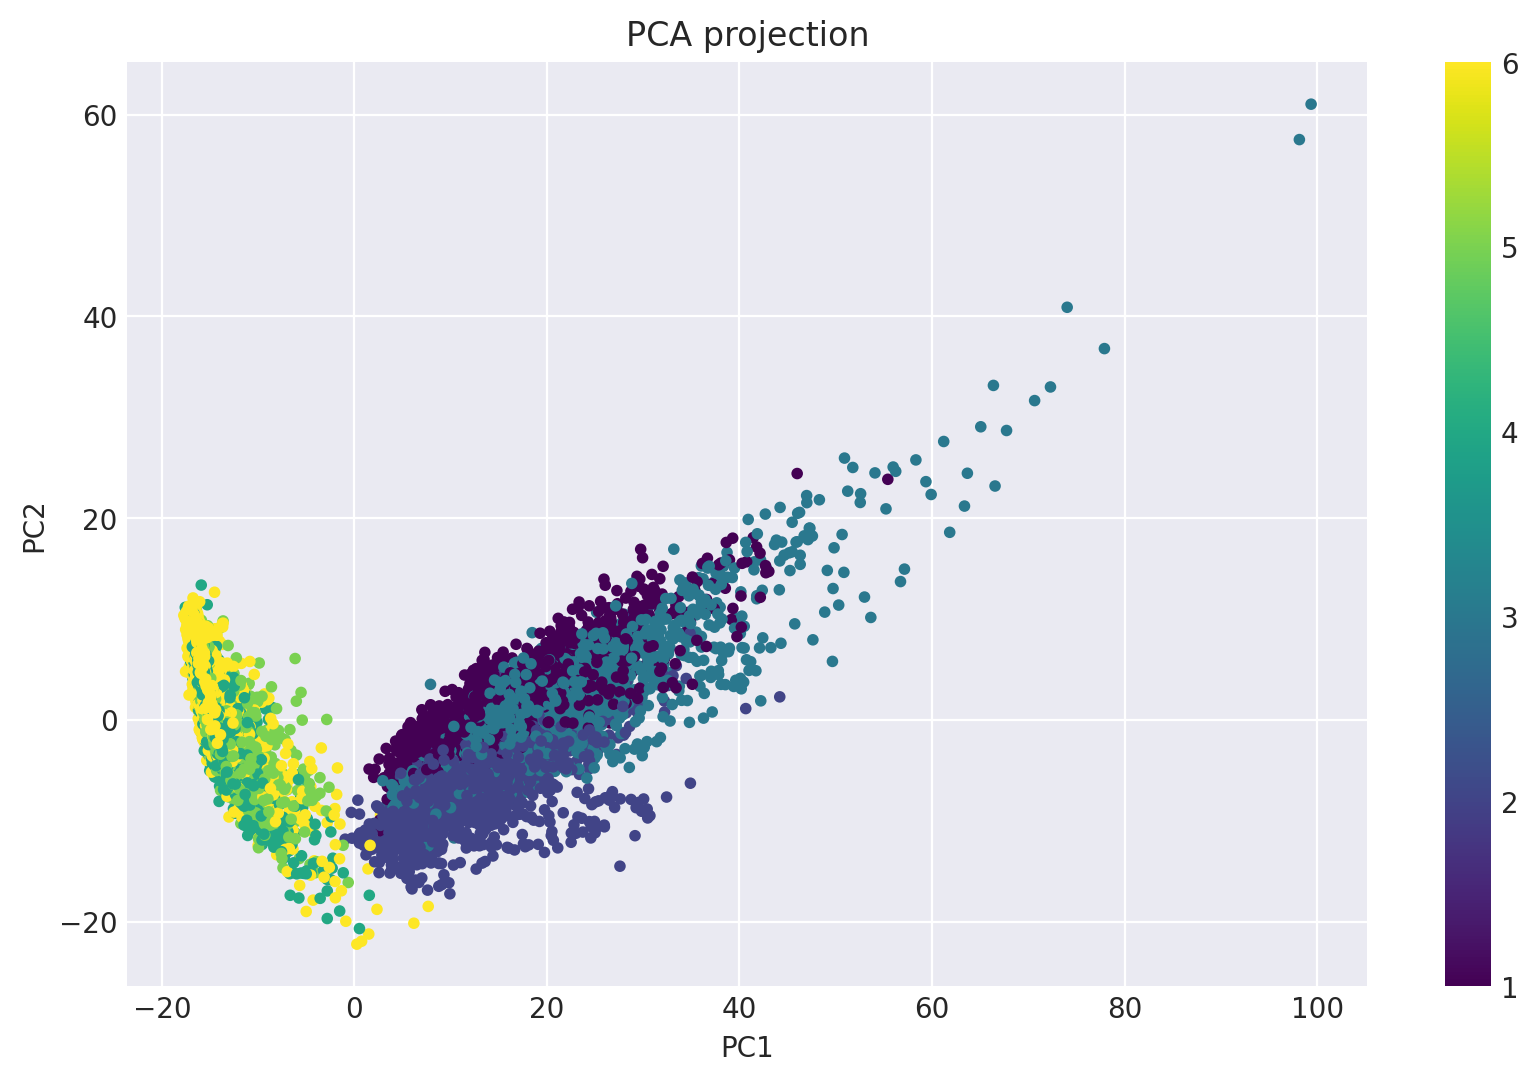

In [116]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='viridis',
    s=10
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection')
plt.colorbar()

plt.show()

### **Задание 19. (0.5 балла)**

Разберёмся с `KMeans`, [doc](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

- Сделайте кластеризацию данных методом `KMeans`, обучив модель на данных со сниженной за счет `PCA` размерностью. Нужно искать 6 кластеров (изначально у нас 6 классов). Засеките время обучения и время инференса.

**Параметры обучения:**

```n_clusters = 6``` (число уникальных меток целевого класса = 6)

```n_init = 100```

```random_state = RANDOM_STATE``` (для воспроизводимости результата, не забывайте указывать его и дальше!)

In [117]:
start = time.time()

kmeans = KMeans(
    n_clusters=6,
    n_init=100,
    random_state=RANDOM_STATE
)

kmeans.fit(X_pca)
train_time = time.time() - start

start = time.time()
clusters = kmeans.predict(X_pca)
pred_time = time.time() - start

print('Train time:', train_time)
print('Predict time:', pred_time)
print(np.unique(clusters))

Train time: 7.2190842628479
Predict time: 0.008190631866455078
[0 1 2 3 4 5]


### **Задание 20 (0.2 балла)**

- Визуализируйте данные в проекции на первые две главные компоненты.
- Раскрасьте точки в соответствии с полученными метками кластеров.

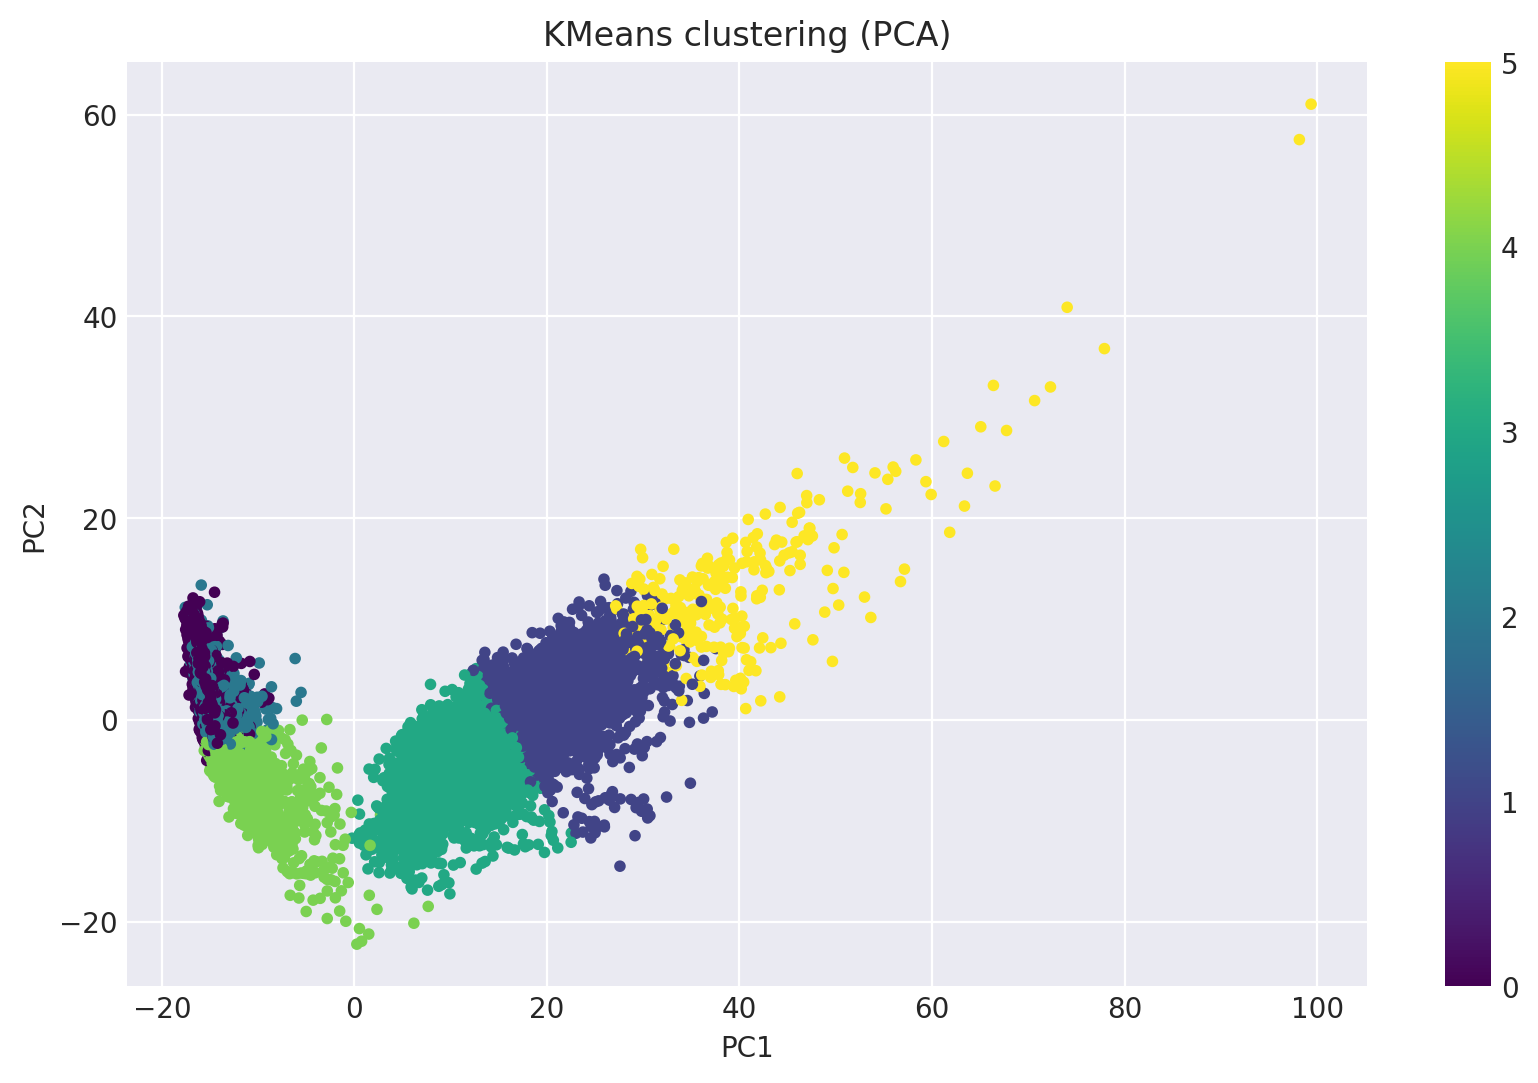

In [118]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis',
    s=10
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans clustering (PCA)')
plt.colorbar()

plt.show()

### **Задание 21 (0.3 балла)**

- Выберите какие-то метрики (минимум две) из известных вам. Объясните свой выбор
- Выведите на экран значения метрик качества, сделайте вывод о них и используйте их далее.

In [119]:
silhouette = silhouette_score(X_pca, clusters)
ari = adjusted_rand_score(y, clusters)

print('Silhouette:', silhouette)
print('ARI:', ari)

Silhouette: 0.14149759467581463
ARI: 0.4194956465790897


Я выбрал silhouette_score и adjusted_rand_score.
Silhouette показывает, насколько хорошо объекты разделены на кластеры без использования правильных меток.
ARI позволяет сравнить полученные кластеры с настоящими классами и оценить качество разбиения.

Silhouette ≈ 0.14 говорит о том, что кластеры разделены слабо, объекты разных кластеров частично пересекаются. Это означает, что структура данных сложная и плохо разделяется простыми методами.

ARI ≈ 0.42 показывает, что кластеры частично совпадают с реальными классами, но совпадение далеко от идеального.

В целом можно сказать, что модель улавливает общую структуру данных, но качество кластеризации среднее.

### **Задание 22 (0.7 баллов)**

Теперь попробуем сделать кластеризацию с помощью `AgglomerativeClustering`, [doc](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

- Засеките время обучения и время инференса. После кластеризации также:
  - Вновь визуализируйте данные с раскраской по полученным меткам
  - Выведите метрики. Засеките время обучения и время инференса. Сравните с ```KMeans```.

Ответьте на следующие вопросы:
* Стало ли лучше?
* Почему?

In [120]:
start = time.time()

agg = AgglomerativeClustering(n_clusters=6)
clusters_agg = agg.fit_predict(X_pca)

train_time_agg = time.time() - start


silhouette_agg = silhouette_score(X_pca, clusters_agg)
ari_agg = adjusted_rand_score(y, clusters_agg)

print('Silhouette:', silhouette_agg)
print('ARI:', ari_agg)
print('Train/predict time:', train_time_agg)

Silhouette: 0.1365817987962443
ARI: 0.49362763373004886
Train/predict time: 7.790781259536743


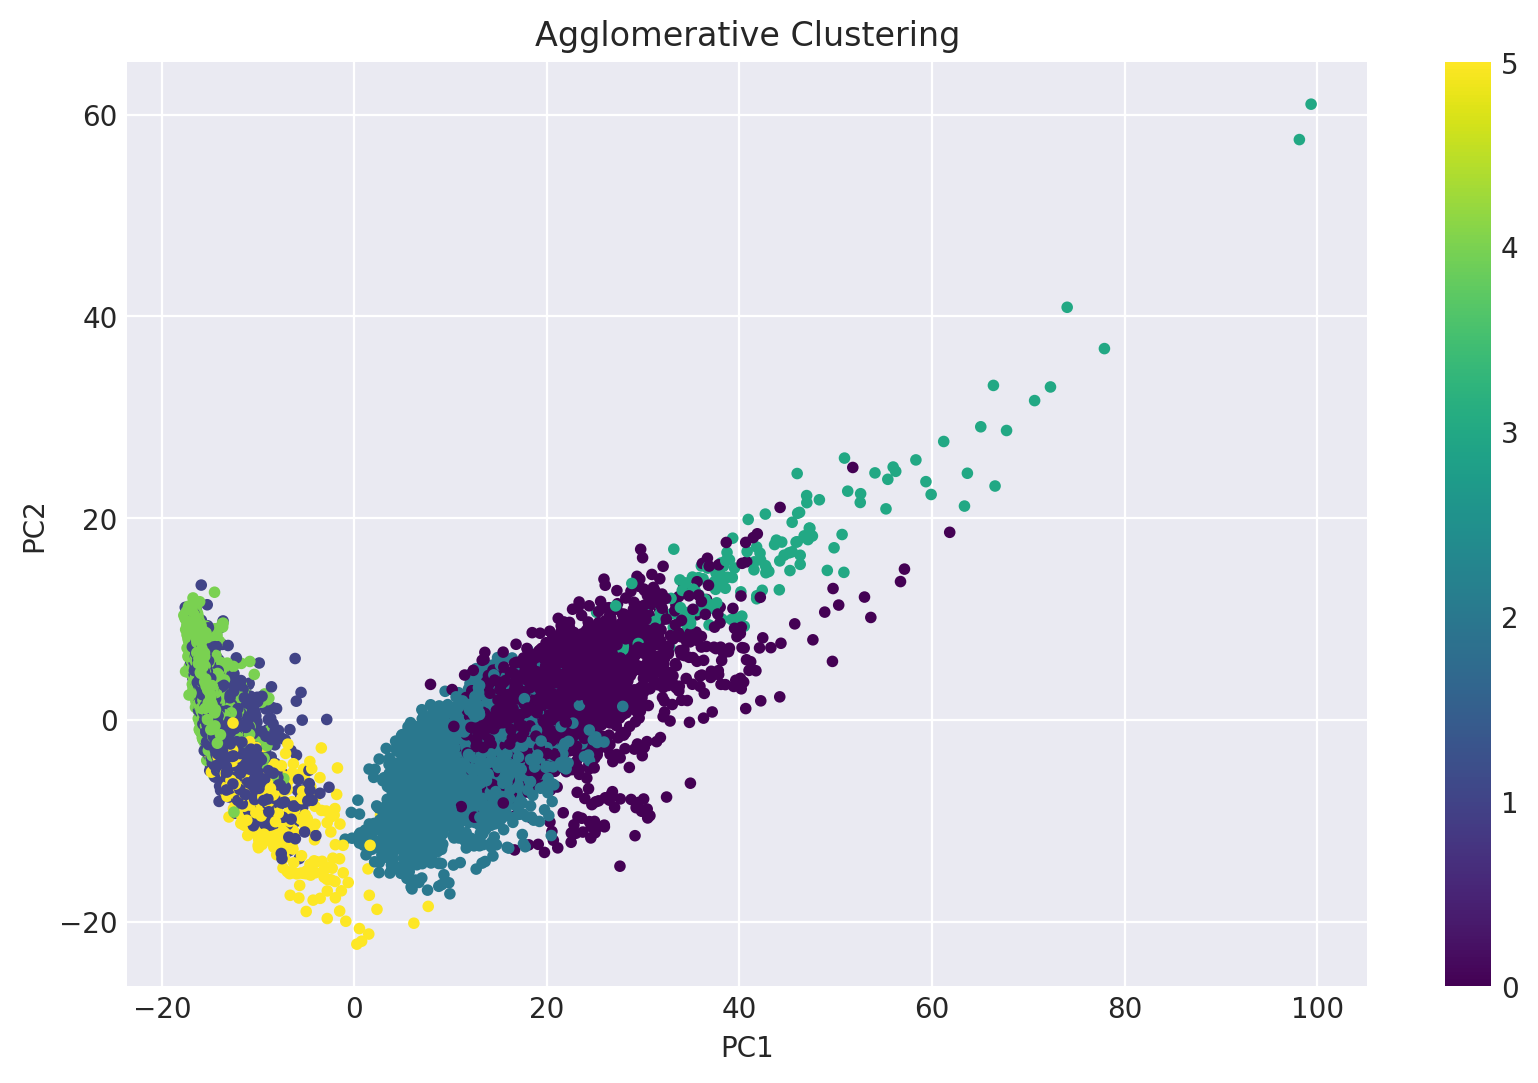

In [121]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_agg,
    cmap='viridis',
    s=10
)

plt.title('Agglomerative Clustering')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar()

plt.show()

Silhouette ≈ 0.137 практически не изменился по сравнению с KMeans (≈ 0.14), что говорит о том, что качество разделения кластеров осталось примерно на том же уровне.

При этом ARI вырос до ≈ 0.49 (было ≈ 0.42), значит разбиение стало лучше соответствовать реальным классам.

Однако время работы значительно увеличилось — AgglomerativeClustering работает заметно медленнее, чем KMeans.

В целом можно сказать, что стало немного лучше по качеству (по ARI), но незначительно, и при этом сильно ухудшилась скорость. Это связано с тем, что агломеративная кластеризация учитывает структуру данных более детально, но хуже масштабируется и требует больше вычислений.

### **Задание 23 (0.3 балла)**
Для самой успешной из полученных кластеризаций попробуйте дать интерпретацию кластеров. Опишите характеристики объектов, попавших в каждый кластер. Для этого можете ответить на следующие вопросы:

* Похожи ли объекты внутри каждого кластера на определенный тип активности человека?
* В каких кластерах смешано несколько типов активности? С чем, на ваш взгляд, это может быть связано?
* Качественная ли получилась кластеризация? На основании чего вы можете сделать такой вывод?

In [122]:
pd.crosstab(clusters_agg, y)

,1,2,3,4,5,6
row_0,,,,,,
0,800,337,1144,0,0,0
1,0,0,0,1559,1832,74
2,896,1207,138,0,0,0
3,26,0,124,0,0,0
4,0,0,0,71,0,1604
5,0,0,0,147,74,266


В целом видно, что кластеры частично соответствуют типам активности, но не идеально.

Кластеры 0 и 2 в основном содержат активности, связанные с движением (ходьба, подъем и спуск по лестнице), то есть модель смогла выделить динамические активности, но внутри них есть заметное смешивание.

Кластер 1 почти полностью состоит из сидения и стояния, значит модель хорошо отделяет статичные состояния, но не различает их между собой.

Кластеры 4 и 5 в основном соответствуют лежанию, но также есть небольшое смешивание с другими классами.

В целом объекты внутри кластеров действительно похожи по типу активности: есть разделение на движение и покой, но более тонкие различия модель уже плохо улавливает.

Смешивание классов происходит в похожих активностях, потому что сигналы датчиков у них близкие.

Качество кластеризации можно считать средним: модель улавливает общую структуру данных, но не может точно разделить все классы.

## **Бонус-задание (1 балл)**
![RedPanda](http://imgur.com/6Aa52Lm.png)

Алгоритмы кластеризации могут применяться в самых разных задачах. Например, в анализе изображений есть задача разделения изображения на семантические компоненты, которую можно решать в том числе с помощью алгоритмов кластеризации. В бонусе предлагаем вам попрактиковаться именно в этом на чудесной утке и совах (```duck.jpg``` и ```owls.jpg```)

### **(0.1 балл)**

- Откройте изображения, после чего визуализируйте их с помощью ```plt.imshow()```

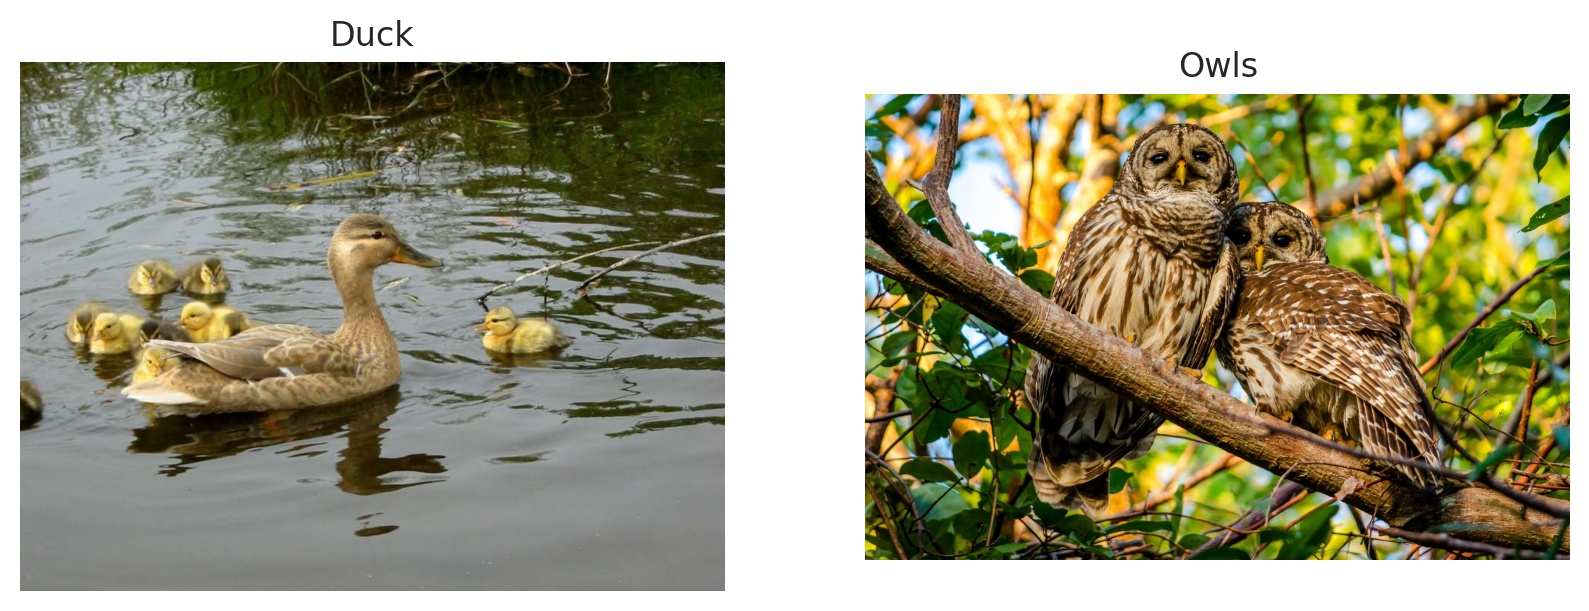

In [123]:
duck = Image.open('duck.jpg')
owls = Image.open('Owls.jpg')

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(duck)
plt.title('Duck')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(owls)
plt.title('Owls')
plt.axis('off')

plt.show()

### **(0.4 балла)**

Для каждого изображения, используя кластеризацию ```KMeans```, выделите компоненты, охарактеризовав каждый пиксель следующим образом: $$\psi_i = [\lambda x_i, \lambda y_i, r_i, g_i, b_i]$$
 где
- $x_i$ и $y_i$ — координаты пикселя,
- $r_i, g_i, b_i$ — его цвет,
- $\lambda$ — параметр, выражающий важность пространственной связности перед цветовой похожестью.

Примените полученную функцию, взяв следующие $\lambda$: 0.3 и 1.5 для ```duck.jpg``` и ```owls.jpg``` (или другие, но тогда с вас красивые результаты :) )

**Примечание:**
Число кластеров подберите разумным образом на свой вкус (в качестве нулевого приближения можно взять 3)

In [124]:
def find_components(image, lmbd, n_clusters):
    img = np.array(image)
    h, w, c = img.shape

    x_coords, y_coords = np.meshgrid(np.arange(w), np.arange(h))

    features = np.stack([
        lmbd * x_coords.ravel(),
        lmbd * y_coords.ravel(),
        img[:, :, 0].ravel(),
        img[:, :, 1].ravel(),
        img[:, :, 2].ravel()
    ], axis=1)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(features)

    segmented = labels.reshape(h, w)

    return segmented

In [125]:
duck_seg = find_components(duck, lmbd=0.3, n_clusters=3)
owls_seg = find_components(owls, lmbd=1.5, n_clusters=3)

### **(0.4 балла)**

Попробуйте выделить сегменты при помощи [спектральной кластеризации](http://scikit-learn.org/stable/modules/clustering.html#spectral-clustering). Обратите внимание на [пример в sklearn](http://scikit-learn.org/0.16/auto_examples/cluster/plot_lena_segmentation.html).


**Примечание:**

Для ускорения работы алгоритма рекомендуется привести изображение к серому цвету. При необходимости можно сжать изображения в 2 раза.

**Подсказка:**```skimage``` с его ```color``` и ```transform``` в этом помогут :)

Или же воспользуйтесь аналогичными средствами ```PIL``` или ```cv2```

In [128]:
def spectral_segmentation(image, n_clusters, beta, eps):
    img = img_as_float(np.array(image))

    img = transform.rescale(img, 0.1, channel_axis=2, anti_aliasing=True)

    gray = color.rgb2gray(img)
    h, w = gray.shape

    graph = img_to_graph(gray)

    graph.data = np.exp(-beta * graph.data / gray.std()) + eps

    model = SpectralClustering(
        n_clusters=n_clusters,
        affinity='precomputed',
        assign_labels='kmeans',
        random_state=42
    )

    labels = model.fit_predict(graph)

    return labels.reshape(h, w)

In [129]:
duck_spec = spectral_segmentation(duck, n_clusters=2, beta=5, eps=1e-6)
owls_spec = spectral_segmentation(owls, n_clusters=2, beta=5, eps=1e-6)

### **(0.1 балл)**
Визуализируйте результаты сегментации (аналогично рисунку в начале задания 2) для обоих методов.

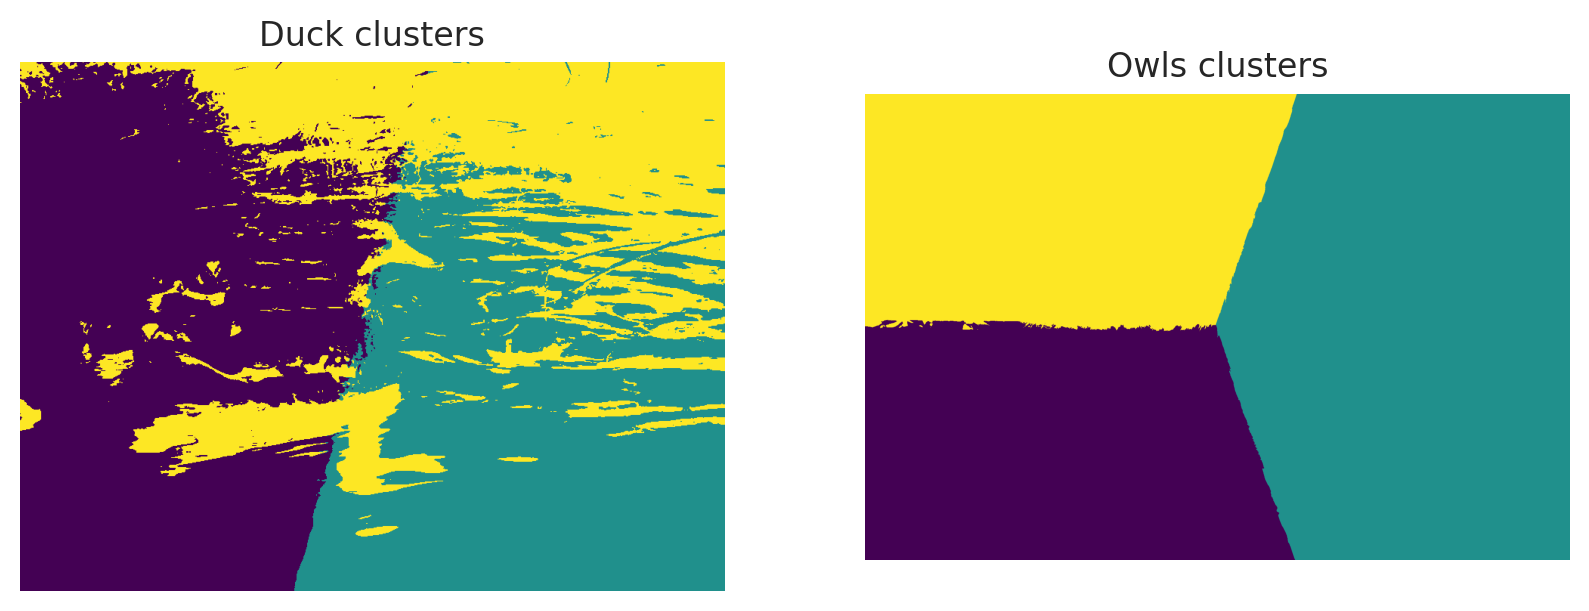

In [130]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(duck_seg, cmap='viridis')
plt.title('Duck clusters')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(owls_seg, cmap='viridis')
plt.title('Owls clusters')
plt.axis('off')

plt.show()

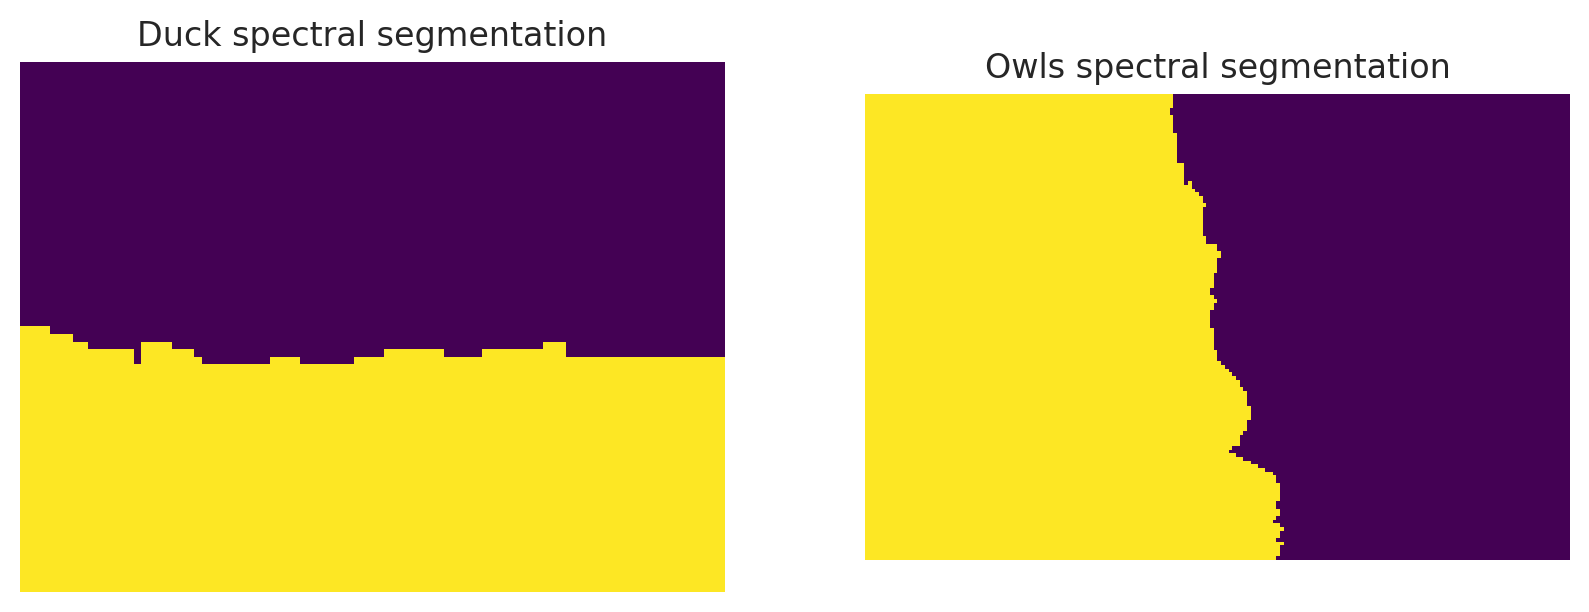

In [131]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(duck_spec, cmap='viridis')
plt.title('Duck spectral segmentation')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(owls_spec, cmap='viridis')
plt.title('Owls spectral segmentation')
plt.axis('off')

plt.show()

**Спасибо! Вы — человек — большой трудяга!**

Успокоительный кот :)

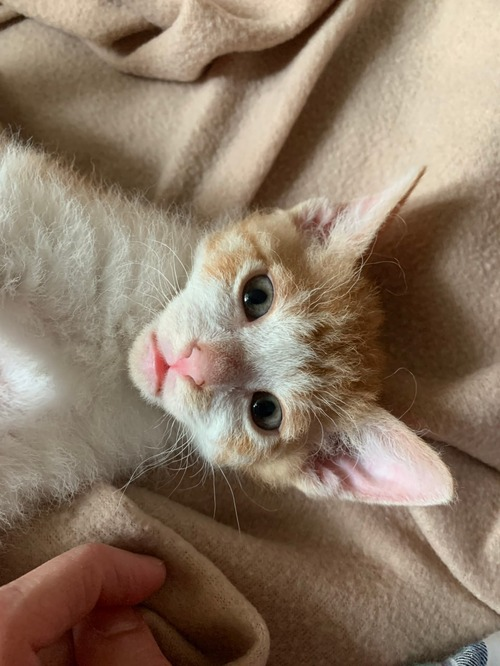